# Retinal Blindness (Diabetic Retinopathy) Detection

This notebook implements a deep learning model for **Diabetic Retinopathy (DR) severity classification** using the [APTOS 2019 Blindness Detection](https://www.kaggle.com/c/aptos2019-blindness-detection) dataset.

## Problem Statement
Diabetic Retinopathy is a disease with increasing prevalence and the leading cause of blindness among working-age populations. Early detection through retinal screening can drastically reduce vision loss.

## Approach
- **Model**: ResNet-152 pretrained on ImageNet, with a custom classification head
- **Classes**: 5 severity levels — No DR (0), Mild (1), Moderate (2), Severe (3), Proliferative DR (4)
- **Strategy**: Transfer learning with partial layer unfreezing

## Motivation
Inspired by the mission of **Aravind Eye Hospital (India)** and the **Asia Pacific Tele-Ophthalmology Society (APTOS)**, this project aims to build an AI-driven screening tool for detecting DR from retinal fundus images.

## 1. Setup & Imports

In [1]:
# Core imports
from __future__ import print_function, division
import os
import copy
import time
import random

# Data & Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image, ImageFile

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torch.optim import lr_scheduler

# Sklearn metrics
from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix, classification_report

# Progress bar
from tqdm.notebook import tqdm

# Allow loading of truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Plotting style
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('bright')

print('All imports successful!')

All imports successful!


## 2. Configuration

In [2]:
# ===================== CONFIGURATION =====================

# Dataset paths (relative to this notebook's location)
BASE_DIR = 'dataset'
TRAIN_CSV_PATH = os.path.join(BASE_DIR, 'train.csv')
TEST_CSV_PATH = os.path.join(BASE_DIR, 'test.csv')
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train_images')
TEST_IMG_DIR = os.path.join(BASE_DIR, 'test_images')

# Model & Training hyperparameters
IMAGE_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 5                # Increase for better accuracy (original used 100+)
INITIAL_LR = 1e-5         # Phase 1: all layers frozen except FC
FINE_TUNE_LR = 1e-6       # Phase 2: with unfrozen layers
VALID_SPLIT = 0.2         # 20% of training data for validation
NUM_CLASSES = 5
STEP_SIZE = 5             # LR scheduler step
GAMMA = 0.1               # LR scheduler decay

# Output
MODEL_SAVE_PATH = 'classifier.pt'

# Class names
CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']

# Seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Training for {EPOCHS} epochs with batch size {BATCH_SIZE}')

Using device: cpu
Training for 5 epochs with batch size 64


## 3. Exploratory Data Analysis (EDA)

### 3.1 Load CSV Data

In [3]:
# Load the CSV files
train_csv = pd.read_csv(TRAIN_CSV_PATH)
test_csv = pd.read_csv(TEST_CSV_PATH)

print(f'Train Size = {len(train_csv)}')
print(f'Test Size  = {len(test_csv)}')
print()
train_csv.head()

Train Size = 3662
Test Size  = 1928



,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


### 3.2 Class Distribution

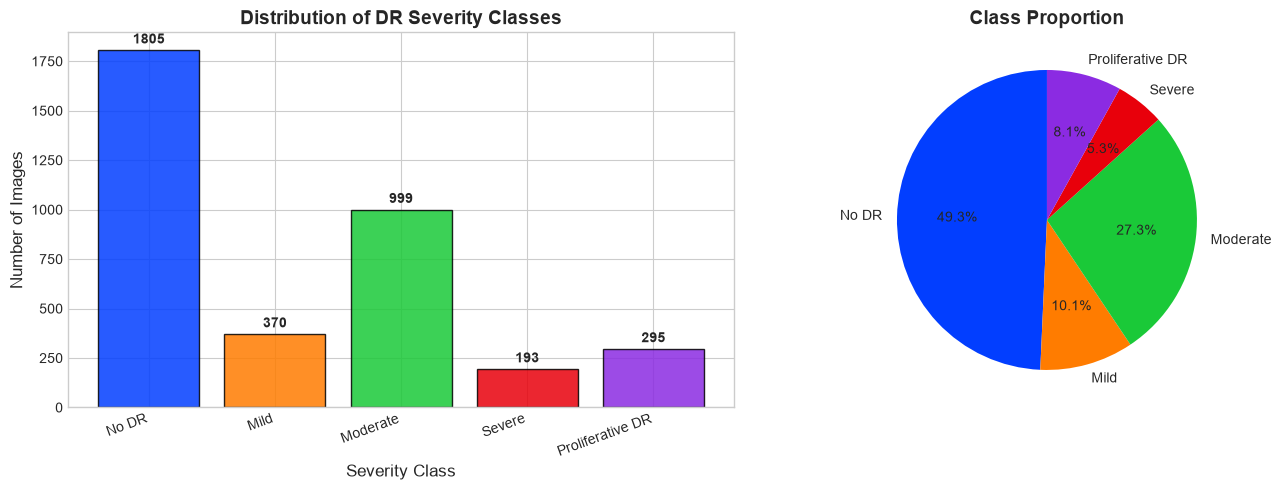


Class distribution:
  0 (No DR): 1805 images (49.3%)
  1 (Mild): 370 images (10.1%)
  2 (Moderate): 999 images (27.3%)
  3 (Severe): 193 images (5.3%)
  4 (Proliferative DR): 295 images (8.1%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
counts = train_csv['diagnosis'].value_counts().sort_index()
ax = axes[0]
bars = ax.bar(range(NUM_CLASSES), [counts.get(i, 0) for i in range(NUM_CLASSES)],
              color=sns.color_palette('bright', NUM_CLASSES), edgecolor='black', alpha=0.85)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
ax.set_title('Distribution of DR Severity Classes', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_xlabel('Severity Class', fontsize=12)
for bar, count in zip(bars, [counts.get(i, 0) for i in range(NUM_CLASSES)]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(count), ha='center', va='bottom', fontweight='bold')

# Pie chart
ax = axes[1]
ax.pie([counts.get(i, 0) for i in range(NUM_CLASSES)],
       labels=CLASS_NAMES, autopct='%1.1f%%',
       colors=sns.color_palette('bright', NUM_CLASSES),
       startangle=90, textprops={'fontsize': 10})
ax.set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nClass distribution:')
for i, name in enumerate(CLASS_NAMES):
    c = counts.get(i, 0)
    print(f'  {i} ({name}): {c} images ({c/len(train_csv)*100:.1f}%)')

### 3.3 Visualize Sample Training Images

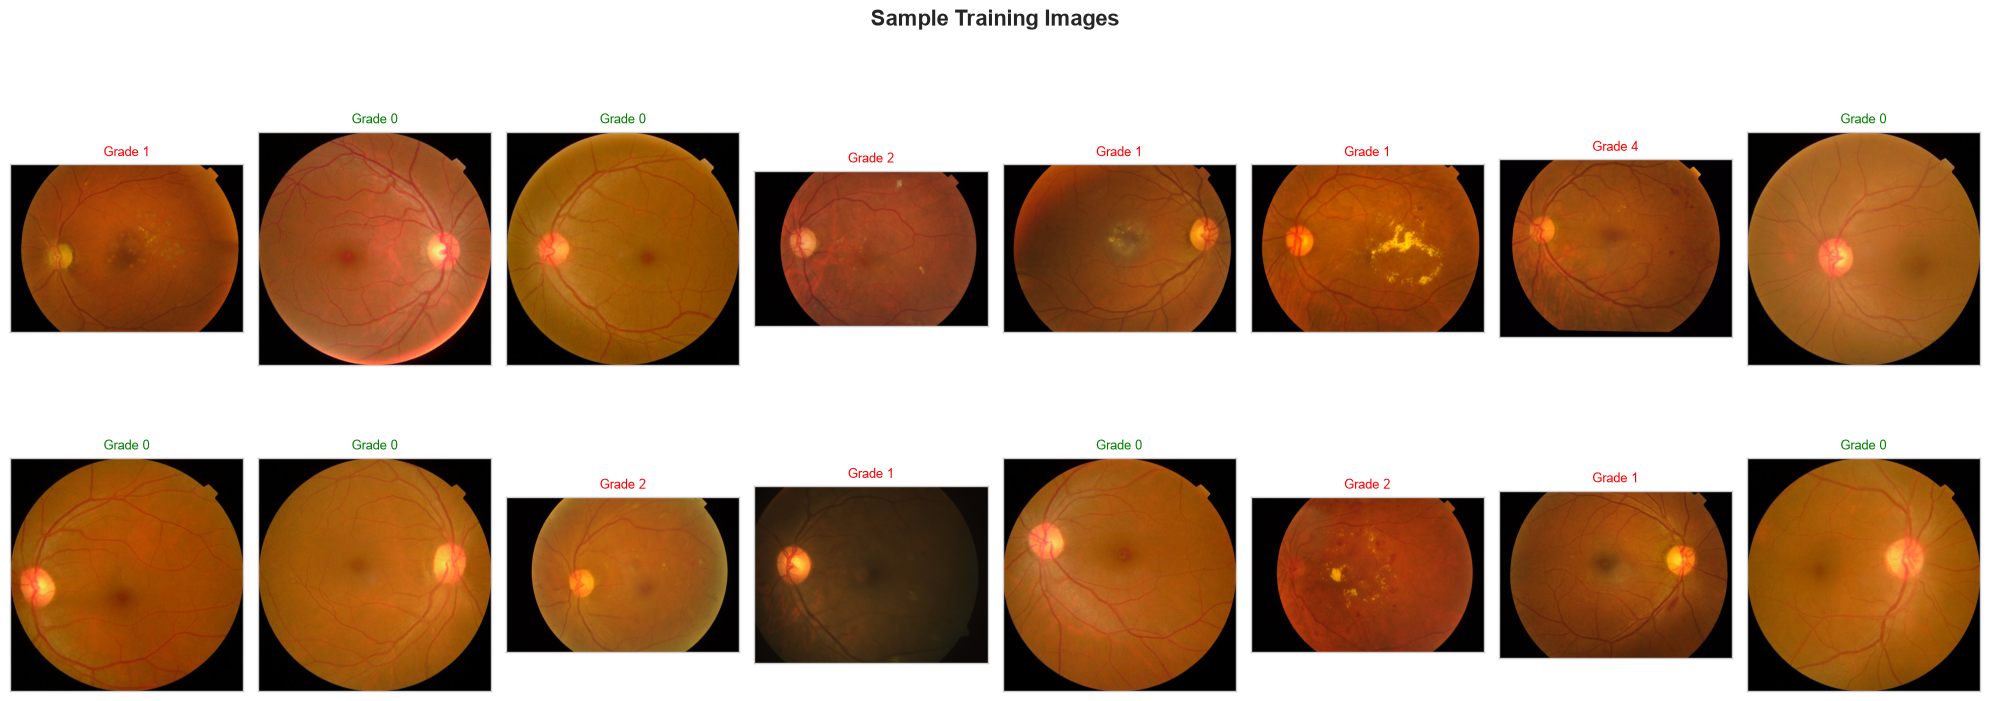

In [5]:
fig = plt.figure(figsize=(20, 8))
fig.suptitle('Sample Training Images', fontsize=16, fontweight='bold')

train_imgs = os.listdir(TRAIN_IMG_DIR)
sample_imgs = np.random.choice(train_imgs, 16, replace=False)

for idx, img_name in enumerate(sample_imgs):
    ax = fig.add_subplot(2, 8, idx + 1, xticks=[], yticks=[])
    im = Image.open(os.path.join(TRAIN_IMG_DIR, img_name))
    ax.imshow(im)
    label = train_csv.loc[train_csv['id_code'] == img_name.split('.')[0], 'diagnosis'].values[0]
    ax.set_title(f'Grade {label}', fontsize=9,
                 color='green' if label == 0 else 'red')

plt.tight_layout()
plt.show()

### 3.4 Visualize Sample Test Images

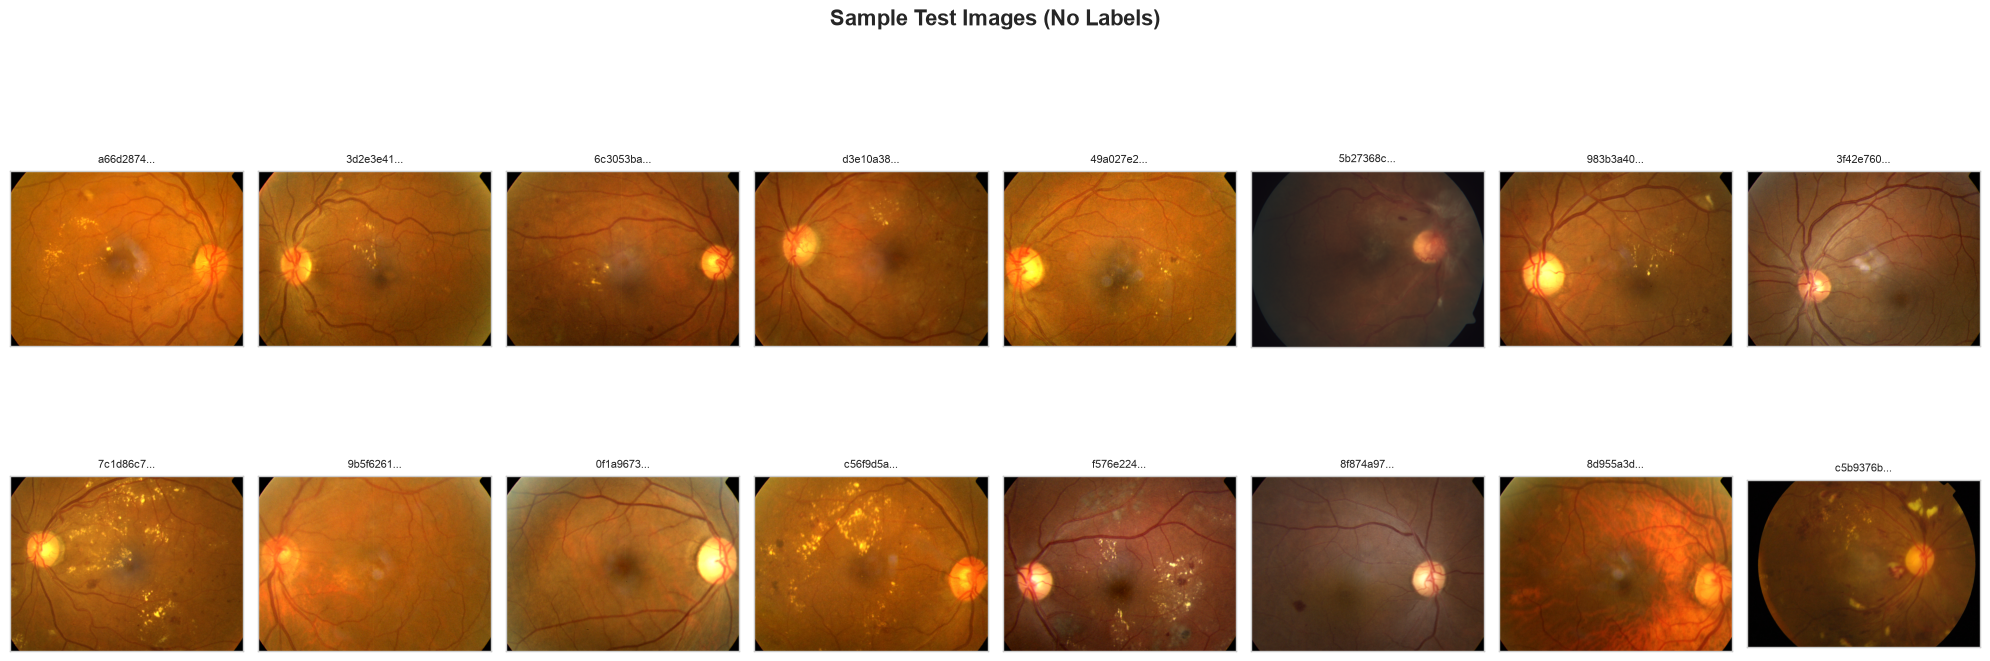

In [6]:
fig = plt.figure(figsize=(20, 8))
fig.suptitle('Sample Test Images (No Labels)', fontsize=16, fontweight='bold')

test_imgs = os.listdir(TEST_IMG_DIR)
sample_test = np.random.choice(test_imgs, 16, replace=False)

for idx, img_name in enumerate(sample_test):
    ax = fig.add_subplot(2, 8, idx + 1, xticks=[], yticks=[])
    im = Image.open(os.path.join(TEST_IMG_DIR, img_name))
    ax.imshow(im)
    ax.set_title(img_name[:8] + '...', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Custom Dataset Class

In [7]:
class RetinalDataset(Dataset):
    """Custom PyTorch Dataset for retinal fundus images.
    
    Args:
        df_data: DataFrame with 'id_code' and optionally 'diagnosis' columns
        data_dir: Path to the image directory
        transform: torchvision transforms to apply
        is_test: If True, only returns images (no labels)
    """
    def __init__(self, df_data, data_dir, transform=None, is_test=False):
        super().__init__()
        self.df = df_data.values
        self.data_dir = data_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        if self.is_test:
            img_name = self.df[index][0]
            label = -1  # placeholder
        else:
            img_name, label = self.df[index]
        
        img_path = os.path.join(self.data_dir, img_name + '.png')
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform is not None:
            image = self.transform(image)
        
        return image, label

## 5. Data Transforms

In [8]:
# Training transforms with data augmentation
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation & test transforms (no augmentation)
val_test_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print('Transforms defined.')

Transforms defined.


## 6. DataLoaders

In [9]:
# Create datasets
train_data = RetinalDataset(
    df_data=train_csv, data_dir=TRAIN_IMG_DIR,
    transform=train_transforms, is_test=False
)

# For validation, we use the same train data but with val transforms
# (handled through sampler — both train and val use train_data)
val_data = RetinalDataset(
    df_data=train_csv, data_dir=TRAIN_IMG_DIR,
    transform=val_test_transforms, is_test=False
)

# Test dataset
test_data = RetinalDataset(
    df_data=test_csv, data_dir=TEST_IMG_DIR,
    transform=val_test_transforms, is_test=True
)

# Train/validation split
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(VALID_SPLIT * num_train))
train_idx, valid_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, sampler=train_sampler)
valid_loader = DataLoader(val_data, batch_size=BATCH_SIZE, sampler=valid_sampler)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

print(f'Training samples:   {len(train_idx)}')
print(f'Validation samples: {len(valid_idx)}')
print(f'Test samples:       {len(test_data)}')
print(f'Train batches: {len(train_loader)}, Valid batches: {len(valid_loader)}, Test batches: {len(test_loader)}')

Training samples:   2930
Validation samples: 732
Test samples:       1928
Train batches: 46, Valid batches: 12, Test batches: 31


### 6.1 Visualize a Training Batch

Batch image shape: torch.Size([64, 3, 224, 224])
Batch label shape: torch.Size([64])


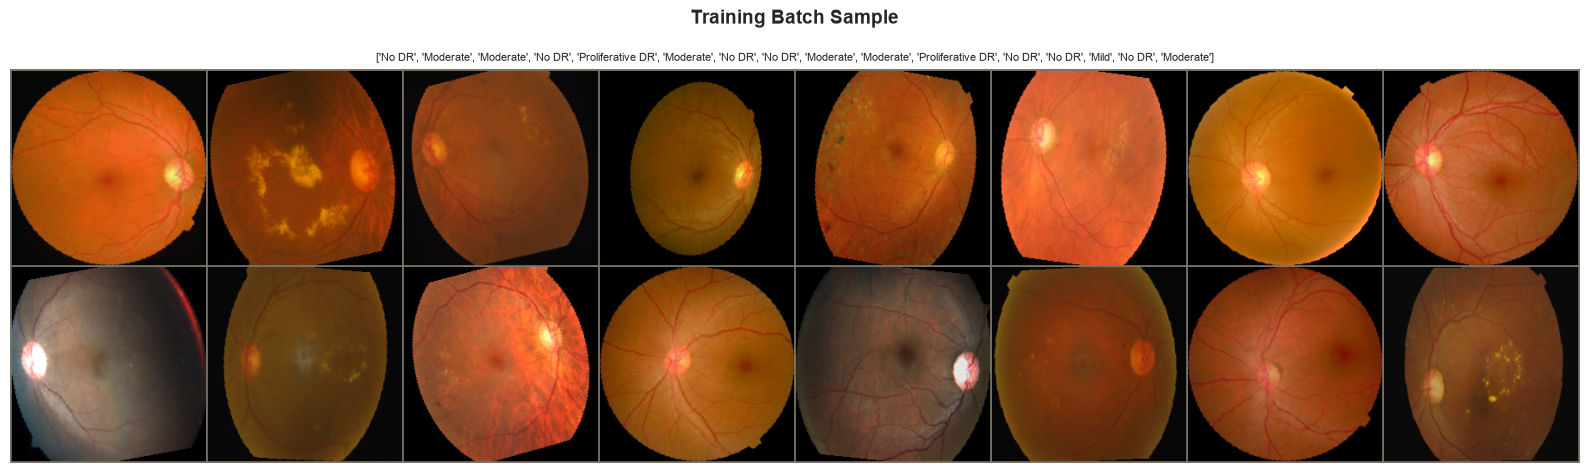

Labels: ['No DR', 'Moderate', 'Moderate', 'No DR', 'Proliferative DR', 'Moderate', 'No DR', 'No DR', 'Moderate', 'Moderate', 'Proliferative DR', 'No DR', 'No DR', 'Mild', 'No DR', 'Moderate']


In [10]:
# Load one batch and visualize
images, labels = next(iter(train_loader))
print(f'Batch image shape: {images.shape}')
print(f'Batch label shape: {labels.shape}')

def imshow_batch(inp, title=None):
    """Display a batch of images (denormalized)."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=8)

# Make grid and show
grid = torchvision.utils.make_grid(images[:16], nrow=8, padding=2)
plt.figure(figsize=(16, 5))
imshow_batch(grid, title=[CLASS_NAMES[x] for x in labels[:16]])
plt.axis('off')
plt.suptitle('Training Batch Sample', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Labels:', [CLASS_NAMES[x] for x in labels[:16].tolist()])

## 7. Model Definition

### Architecture
- **Base**: ResNet-152 pretrained on ImageNet
- **Custom Head**: `Linear(2048 → 512) → ReLU → Linear(512 → 5) → LogSoftmax`
- **Freeze Strategy**: Freeze early layers (`conv1`, `bn1`, `relu`, `maxpool`, `layer1`), unfreeze deeper layers (`layer2`, `layer3`, `layer4`, `fc`)

In [11]:
def build_model():
    """Build the ResNet-152 model with custom classification head."""
    # Load pretrained ResNet-152
    model = models.resnet152(weights='IMAGENET1K_V1')
    
    # Replace the final FC layer with our custom head
    num_ftrs = model.fc.in_features  # 2048 for ResNet-152
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Linear(512, NUM_CLASSES),
        nn.LogSoftmax(dim=1)
    )
    
    # Freeze/unfreeze layers
    layers_to_unfreeze = ['layer2', 'layer3', 'layer4', 'fc']
    for name, child in model.named_children():
        if name in layers_to_unfreeze:
            for param in child.parameters():
                param.requires_grad = True
            print(f'  ✓ {name} — unfrozen')
        else:
            for param in child.parameters():
                param.requires_grad = False
            print(f'  ✗ {name} — frozen')
    
    model = model.to(device)
    
    # Count trainable parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f'\nTrainable parameters: {trainable_params:,} / {total_params:,} '
          f'({trainable_params/total_params*100:.1f}%)')
    
    return model

print('Building model...')
model = build_model()

Building model...
  ✗ conv1 — frozen
  ✗ bn1 — frozen
  ✗ relu — frozen
  ✗ maxpool — frozen
  ✗ layer1 — frozen
  ✓ layer2 — unfrozen
  ✓ layer3 — unfrozen
  ✓ layer4 — unfrozen
  ✗ avgpool — frozen
  ✓ fc — unfrozen

Trainable parameters: 58,970,117 / 59,195,461 (99.6%)


In [12]:
# Loss function, optimizer, and scheduler
criterion = nn.NLLLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=FINE_TUNE_LR
)
scheduler = lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

print(f'Loss: NLLLoss')
print(f'Optimizer: Adam (lr={FINE_TUNE_LR})')
print(f'Scheduler: StepLR (step_size={STEP_SIZE}, gamma={GAMMA})')

Loss: NLLLoss
Optimizer: Adam (lr=1e-06)
Scheduler: StepLR (step_size=5, gamma=0.1)


## 8. Training

In [ ]:
def train_and_validate(model, train_loader, valid_loader, criterion, optimizer,
                        scheduler, epochs, save_path, resume=True):
    """Train the model and validate at each epoch.
    
    Args:
        resume: If True, automatically resumes training from save_path if it exists.
        
    Returns:
        train_losses, valid_losses, valid_accuracies (lists)
    """
    train_losses = []
    valid_losses = []
    valid_accuracies = []
    valid_loss_min = np.inf
    best_accuracy = 0.0
    start_epoch = 0

    # Auto-resume from existing checkpoint if available
    if resume and os.path.exists(save_path):
        print(f"--> Found existing checkpoint at '{save_path}'. Loading state...")
        checkpoint = torch.load(save_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        if 'optimizer_state_dict' in checkpoint:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint.get('epoch', -1) + 1
        valid_loss_min = checkpoint.get('valid_loss', np.inf)
        best_accuracy = checkpoint.get('valid_accuracy', 0.0)
        print(f"--> Successfully resumed from Epoch {start_epoch + 1}/{epochs}")
        print(f"    Previous Best Validation Loss: {valid_loss_min:.4f} | Accuracy: {best_accuracy*100:.2f}%")
        
        if start_epoch >= epochs:
            print(f"--> Model has already completed {start_epoch} of {epochs} epochs!")
            print(f"    If you want to train more epochs, pass epochs={start_epoch + 5} or update EPOCHS in config.")
            print("    Skipping training loop. You can proceed directly to Evaluation (Section 10)!")
            return train_losses, valid_losses, valid_accuracies

    print('=' * 60)
    print(f'Model Training {"Resumed" if start_epoch > 0 else "Started"}')
    print('=' * 60)
    start_time = time.time()
    
    for epoch in range(start_epoch, epochs):
        epoch_start = time.time()
        
        # ---- Training Phase ----
        model.train()
        running_loss = 0.0
        
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]',
                         leave=False)
        for batch_idx, (images, labels) in enumerate(train_bar):
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            train_bar.set_postfix(loss=f'{loss.item():.4f}')
        
        avg_train_loss = running_loss / len(train_loader)
        
        # ---- Validation Phase ----
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            val_bar = tqdm(valid_loader, desc=f'Epoch {epoch+1}/{epochs} [Valid]',
                           leave=False)
            for images, labels in val_bar:
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                # Calculate accuracy
                ps = torch.exp(outputs)
                _, predicted = ps.topk(1, dim=1)
                predicted = predicted.squeeze(1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        
        avg_val_loss = val_loss / len(valid_loader)
        val_accuracy = correct / total
        
        # Step the scheduler
        scheduler.step()
        
        # Record metrics
        train_losses.append(avg_train_loss)
        valid_losses.append(avg_val_loss)
        valid_accuracies.append(val_accuracy)
        
        epoch_time = time.time() - epoch_start
        
        # Print epoch summary
        print(f'Epoch {epoch+1}/{epochs} ({epoch_time:.0f}s) | '
              f'Train Loss: {avg_train_loss:.4f} | '
              f'Valid Loss: {avg_val_loss:.4f} | '
              f'Valid Acc: {val_accuracy:.4f}')
        
        # Save best model
        if avg_val_loss <= valid_loss_min:
            print(f'  → Validation loss decreased ({valid_loss_min:.6f} → {avg_val_loss:.6f}). Saving model...')
            torch.save({
                'epoch': epoch,
                'model': model,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': avg_train_loss,
                'valid_loss': avg_val_loss,
                'valid_accuracy': val_accuracy,
            }, save_path)
            valid_loss_min = avg_val_loss
            best_accuracy = val_accuracy
    
    total_time = time.time() - start_time
    print('=' * 60)
    print(f'Training Completed in {total_time/60:.1f} minutes')
    print(f'Best Validation Loss: {valid_loss_min:.4f}')
    print(f'Best Validation Accuracy: {best_accuracy:.4f}')
    print('=' * 60)
    
    return train_losses, valid_losses, valid_accuracies

### 8.1 Run Training

In [14]:
# Train or resume training from checkpoint (classifier.pt)
train_losses, valid_losses, valid_accuracies = train_and_validate(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=EPOCHS,
    save_path=MODEL_SAVE_PATH,
    resume=True  # Automatically resumes from checkpoint if exists
)

AttributeError: `np.Inf` was removed in the NumPy 2.0 release. Use `np.inf` instead.

## 9. Training Results

In [15]:
# Check if training metrics exist in memory or checkpoint
if 'train_losses' in globals() and train_losses:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs_range = list(range(1, len(train_losses) + 1))
    
    # Loss plot
    ax = axes[0]
    ax.plot(epochs_range, train_losses, 'o-', label='Train Loss', linewidth=2)
    ax.plot(epochs_range, valid_losses, 's-', label='Validation Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    # Accuracy plot
    ax = axes[1]
    ax.plot(epochs_range, [a * 100 for a in valid_accuracies], 'D-',
            color='green', label='Validation Accuracy', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print()
    print(f'Final Training Loss:       {train_losses[-1]:.4f}')
    print(f'Final Validation Loss:     {valid_losses[-1]:.4f}')
    print(f'Final Validation Accuracy: {valid_accuracies[-1]*100:.2f}%')
elif 'MODEL_SAVE_PATH' in globals() and os.path.exists(MODEL_SAVE_PATH):
    # If training was skipped or interrupted, display metrics stored in the checkpoint
    ckpt = torch.load(MODEL_SAVE_PATH, map_location='cpu', weights_only=False)
    print('Checkpoint found! Displaying metrics from saved checkpoint (classifier.pt):')
    print(f'  Saved at Epoch:            {ckpt.get("epoch", 0) + 1}')
    print(f'  Training Loss:             {ckpt.get("train_loss", 0.0):.4f}')
    print(f'  Best Validation Loss:      {ckpt.get("valid_loss", 0.0):.4f}')
    print(f'  Best Validation Accuracy:  {ckpt.get("valid_accuracy", 0.0)*100:.2f}%')
else:
    print('No training metrics or checkpoint found. Run Section 8 first.')

Checkpoint found! Displaying metrics from saved checkpoint (classifier.pt):
  Saved at Epoch:            5
  Training Loss:             1.0783
  Best Validation Loss:      1.0578
  Best Validation Accuracy:  66.53%


## 10. Evaluation on Validation Set

In [16]:
# Load the best saved model
import os
import torch
import torch.nn as nn
from torchvision import models

MODEL_SAVE_PATH = 'classifier.pt'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# If model is not defined in memory yet, build the architecture
if 'model' not in globals() or model is None:
    print('Initializing ResNet-152 model architecture...')
    model = models.resnet152(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Linear(512, 5),  # 5 classes
        nn.LogSoftmax(dim=1)
    )
    model = model.to(device)

# Load saved weights
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'✓ Successfully loaded best model from epoch {checkpoint["epoch"] + 1}')
print(f'  Validation Loss: {checkpoint["valid_loss"]:.4f}')
print(f'  Validation Accuracy: {checkpoint["valid_accuracy"]*100:.2f}%')

✓ Successfully loaded best model from epoch 5
  Validation Loss: 1.0578
  Validation Accuracy: 66.53%


In [17]:
# Full evaluation on validation set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(valid_loader, desc='Evaluating'):
        images = images.to(device)
        outputs = model(images)
        ps = torch.exp(outputs)
        _, predicted = ps.topk(1, dim=1)
        all_preds.extend(predicted.squeeze(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification report
print('\nClassification Report:')
print('=' * 60)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Cohen's Kappa Score (important for ordinal classification)
kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
print(f'Quadratic Weighted Kappa: {kappa:.4f}')

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]


Classification Report:
                  precision    recall  f1-score   support

           No DR       0.74      0.99      0.85       351
            Mild       0.00      0.00      0.00        85
        Moderate       0.53      0.70      0.60       201
          Severe       0.00      0.00      0.00        40
Proliferative DR       0.00      0.00      0.00        55

        accuracy                           0.67       732
       macro avg       0.25      0.34      0.29       732
    weighted avg       0.50      0.67      0.57       732

Quadratic Weighted Kappa: 0.5675


/Users/param/IIC26/backend/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/param/IIC26/backend/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/param/IIC26/backend/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

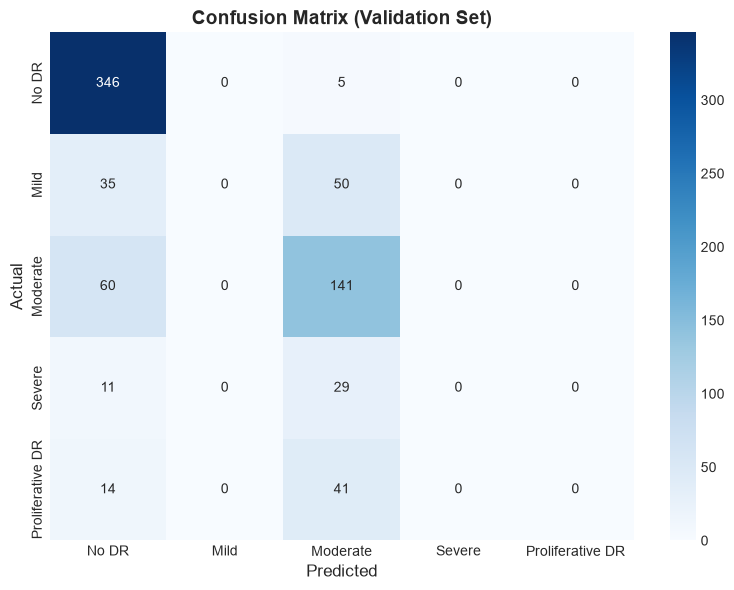

In [18]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix (Validation Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Inference on Test Set

In [19]:
# Run inference on test images
model.eval()
test_predictions = []

with torch.no_grad():
    for images, _ in tqdm(test_loader, desc='Test Inference'):
        images = images.to(device)
        outputs = model(images)
        ps = torch.exp(outputs)
        _, predicted = ps.topk(1, dim=1)
        test_predictions.extend(predicted.squeeze(1).cpu().numpy())

test_predictions = np.array(test_predictions)

# Create submission dataframe
submission = pd.DataFrame({
    'id_code': test_csv['id_code'],
    'diagnosis': test_predictions
})

print(f'Total test predictions: {len(submission)}')
print(f'\nPrediction distribution:')
for i, name in enumerate(CLASS_NAMES):
    count = (test_predictions == i).sum()
    print(f'  {i} ({name}): {count} ({count/len(test_predictions)*100:.1f}%)')

submission.head(10)

Test Inference:   0%|          | 0/31 [00:00<?, ?it/s]

Total test predictions: 1928

Prediction distribution:
  0 (No DR): 1302 (67.5%)
  1 (Mild): 0 (0.0%)
  2 (Moderate): 626 (32.5%)
  3 (Severe): 0 (0.0%)
  4 (Proliferative DR): 0 (0.0%)


,id_code,diagnosis
0,0005cfc8afb6,0
1,003f0afdcd15,0
2,006efc72b638,2
3,00836aaacf06,0
4,009245722fa4,2
5,009c019a7309,0
6,010d915e229a,2
7,0111b949947e,0
8,01499815e469,2
9,0167076e7089,0


In [20]:
# Save submission
submission.to_csv('submission.csv', index=False)
print('Submission saved to submission.csv')

Submission saved to submission.csv


## 12. Sample Predictions Visualization

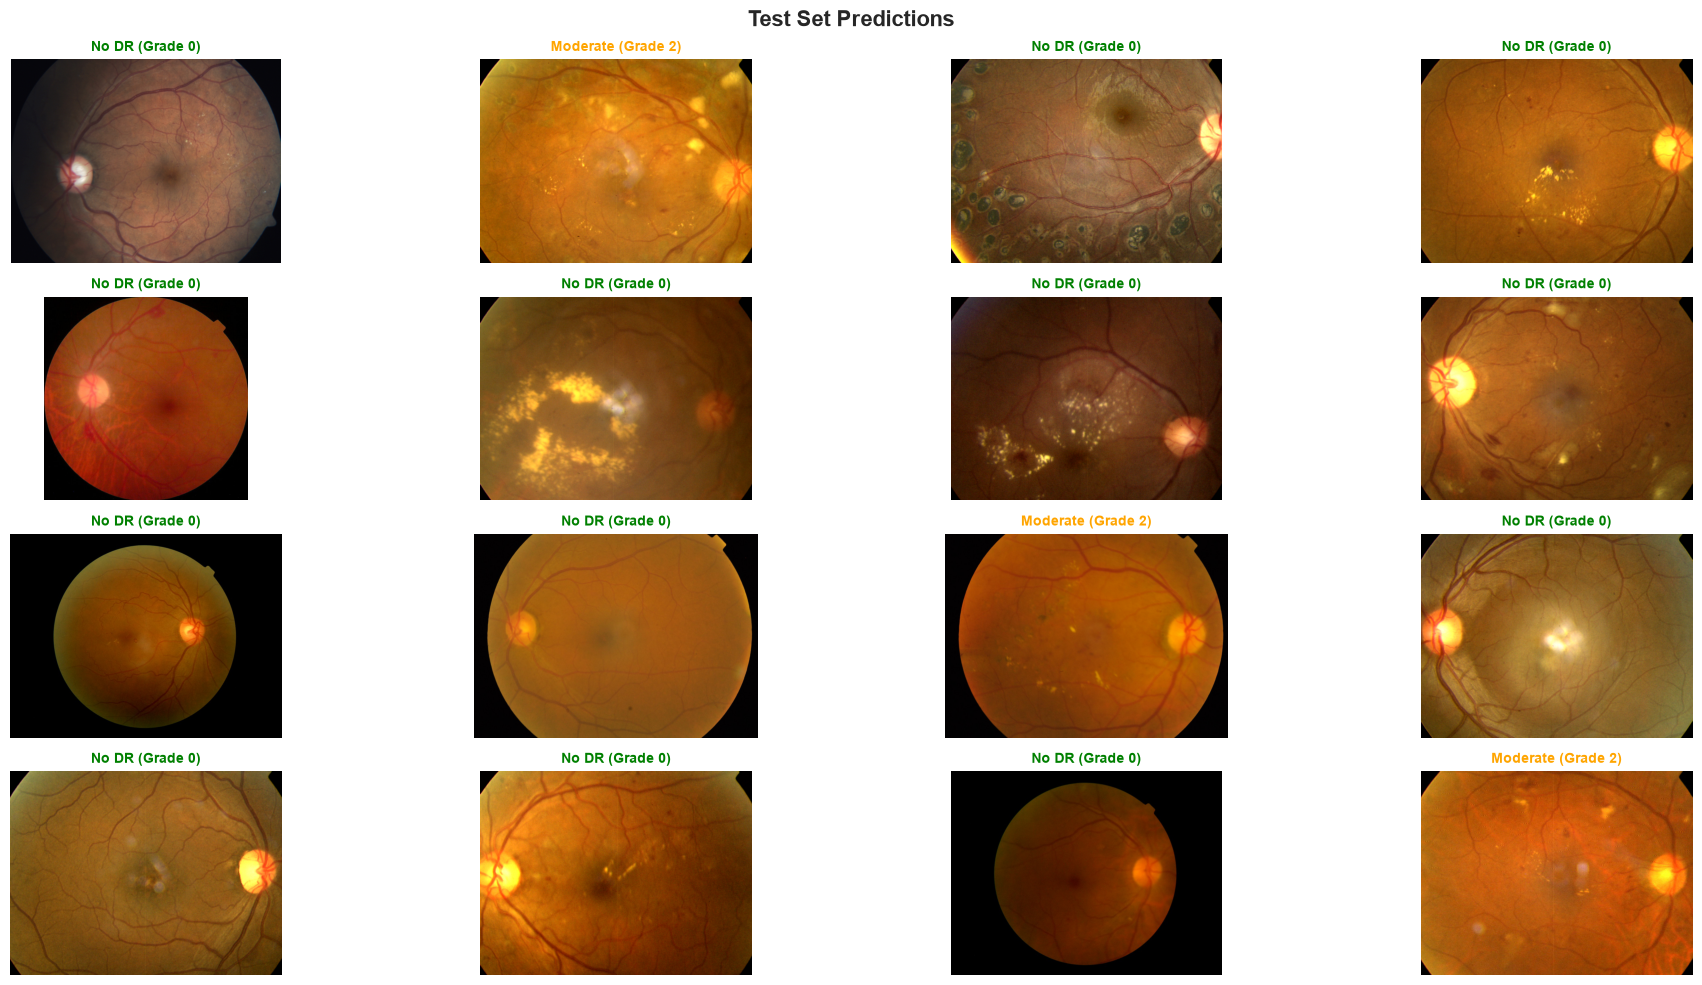

In [21]:
def visualize_predictions(test_csv, test_img_dir, predictions, n=16):
    """Display test images with their predicted severity labels."""
    fig = plt.figure(figsize=(20, 10))
    fig.suptitle('Test Set Predictions', fontsize=16, fontweight='bold')
    
    indices = np.random.choice(len(predictions), min(n, len(predictions)), replace=False)
    
    cols = 4
    rows = (n + cols - 1) // cols
    
    for i, idx in enumerate(indices):
        ax = fig.add_subplot(rows, cols, i + 1)
        
        img_name = test_csv.iloc[idx]['id_code']
        img_path = os.path.join(test_img_dir, img_name + '.png')
        img = Image.open(img_path)
        ax.imshow(img)
        
        pred = predictions[idx]
        color = 'green' if pred == 0 else ('orange' if pred <= 2 else 'red')
        ax.set_title(f'{CLASS_NAMES[pred]} (Grade {pred})',
                     fontsize=10, color=color, fontweight='bold')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_predictions(test_csv, TEST_IMG_DIR, test_predictions, n=16)

## 13. Single Image Inference

Testing on: 34fb98396a24.png


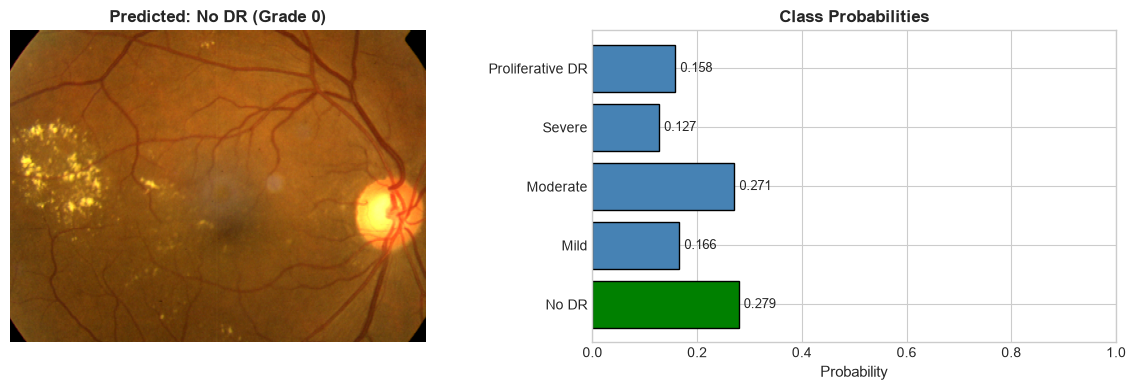


Predicted Severity: 0 (No DR)


In [22]:
def predict_single_image(model, image_path, transform, class_names):
    """Run inference on a single retinal image.
    
    Args:
        model: trained model
        image_path: path to the image file
        transform: preprocessing transforms
        class_names: list of class names
    
    Returns:
        predicted_class (int), class_name (str), probabilities (tensor)
    """
    # Load and transform image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_tensor = transform(image_rgb).unsqueeze(0).to(device)
    
    # Inference
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.exp(output).squeeze()
        predicted_class = probabilities.argmax().item()
    
    # Display
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Show image
    axes[0].imshow(Image.open(image_path))
    axes[0].set_title(f'Predicted: {class_names[predicted_class]} (Grade {predicted_class})',
                      fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Show probabilities
    probs = probabilities.cpu().numpy()
    colors = ['green' if i == predicted_class else 'steelblue' for i in range(len(class_names))]
    axes[1].barh(class_names, probs, color=colors, edgecolor='black')
    axes[1].set_xlabel('Probability', fontsize=11)
    axes[1].set_title('Class Probabilities', fontsize=12, fontweight='bold')
    axes[1].set_xlim(0, 1)
    for i, (p, name) in enumerate(zip(probs, class_names)):
        axes[1].text(p + 0.01, i, f'{p:.3f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return predicted_class, class_names[predicted_class], probabilities

# Example: run on a random test image
test_imgs = os.listdir(TEST_IMG_DIR)
sample_img = np.random.choice(test_imgs)
sample_path = os.path.join(TEST_IMG_DIR, sample_img)
print(f'Testing on: {sample_img}')

pred_class, pred_name, probs = predict_single_image(
    model, sample_path, val_test_transforms, CLASS_NAMES
)
print(f'\nPredicted Severity: {pred_class} ({pred_name})')